# Spotify Popularity Predictor – Phase 1
Data preparation, model training (Random Forest) and export of training data for browser deployment.

## Imports
- Pandas, NumPy for data processing
- Scikit-learn for model, metrics & preprocessing
- Matplotlib, Seaborn for visualisations
- JSON for export

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

sns.set_theme(style="darkgrid")

## Load Data
- Read CSV file (Latin-1 encoding)
- Display first rows

In [3]:
df = pd.read_csv("Most Streamed Spotify Songs 2024.csv", encoding="latin1")
df.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


## Data Cleaning
- Convert numeric columns to correct types
- Remove commas from numbers
- Display descriptive statistics

In [4]:
numeric_cols = [
    "Spotify Streams", "Spotify Playlist Count", "Spotify Playlist Reach",
    "YouTube Views", "YouTube Likes", "TikTok Posts", "TikTok Likes",
    "TikTok Views", "YouTube Playlist Reach", "Apple Music Playlist Count",
    "AirPlay Spins", "SiriusXM Spins", "Deezer Playlist Count",
    "Deezer Playlist Reach", "Amazon Playlist Count", "Pandora Streams",
    "Pandora Track Stations", "Soundcloud Streams", "Shazam Counts"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

df.describe()

,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
count,4600.000000,4.487000e+03,4530.000000,4.528000e+03,3796.000000,4.292000e+03,4.285000e+03,3.427000e+03,3.620000e+03,3.619000e+03,...,2477.000000,3679.000000,3.672000e+03,3545.000000,3.494000e+03,3.332000e+03,1.267000e+03,4.023000e+03,0.0,4600.000000
mean,41.844043,4.473873e+08,59390.829801,2.334682e+07,63.501581,4.027967e+08,2.930049e+06,9.443076e+05,1.126375e+08,1.161158e+09,...,257.344368,32.310954,1.294939e+06,25.348942,8.566735e+07,8.787697e+04,1.484797e+07,2.529149e+06,NaN,0.358913
std,38.543766,5.384439e+08,71131.406625,2.968717e+07,16.186438,7.019000e+08,4.593640e+06,2.442080e+06,5.498123e+08,5.881584e+09,...,554.737321,54.274538,3.555543e+06,25.989826,1.678785e+08,2.608537e+05,3.213281e+07,6.038786e+06,NaN,0.479734
min,19.400000,1.071000e+03,1.000000,1.000000e+00,1.000000,9.130000e+02,2.500000e+01,1.000000e+00,3.000000e+00,1.900000e+01,...,1.000000,1.000000,1.000000e+00,1.000000,2.000000e+00,1.000000e+00,1.800000e+01,1.000000e+00,NaN,0.000000
25%,23.300000,7.038630e+07,6718.000000,4.791612e+06,61.000000,4.073032e+07,4.095490e+05,3.818650e+04,5.814876e+06,5.902786e+07,...,25.000000,5.000000,5.216600e+04,8.000000,1.057955e+06,1.261500e+03,7.684075e+05,2.301950e+05,NaN,0.000000
50%,29.900000,2.398507e+08,32312.500000,1.325948e+07,67.000000,1.482696e+08,1.257935e+06,1.822000e+05,2.653441e+07,2.659172e+08,...,86.000000,15.000000,2.371205e+05,17.000000,1.273577e+07,7.832000e+03,3.224599e+06,8.545840e+05,NaN,0.000000
75%,44.425000,6.283638e+08,86038.750000,2.966069e+07,73.000000,4.647882e+08,3.573193e+06,7.948775e+05,9.328418e+07,9.134169e+08,...,255.000000,37.000000,9.063012e+05,34.000000,8.150121e+07,4.922400e+04,1.338760e+07,2.684638e+06,NaN,1.000000
max,725.400000,4.281469e+09,590392.000000,2.623434e+08,96.000000,1.632276e+10,6.231118e+07,4.290000e+07,2.347422e+10,2.332323e+11,...,7098.000000,632.000000,4.819785e+07,210.000000,1.463624e+09,3.780513e+06,3.198359e+08,2.197945e+08,NaN,1.000000


## Explorative Datenanalyse (EDA)
Basic visualisations to understand the distribution and relationships within the data.

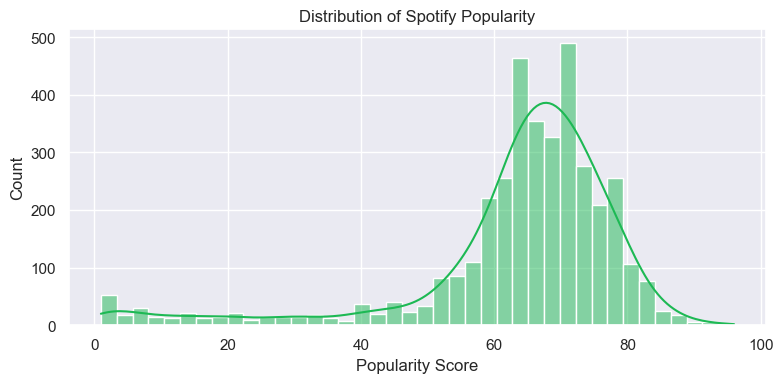

In [5]:
# Distribution of the target variable
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Spotify Popularity"].dropna(), bins=40, kde=True, ax=ax, color="#1db954")
ax.set_title("Distribution of Spotify Popularity")
ax.set_xlabel("Popularity Score")
plt.tight_layout()
plt.show()

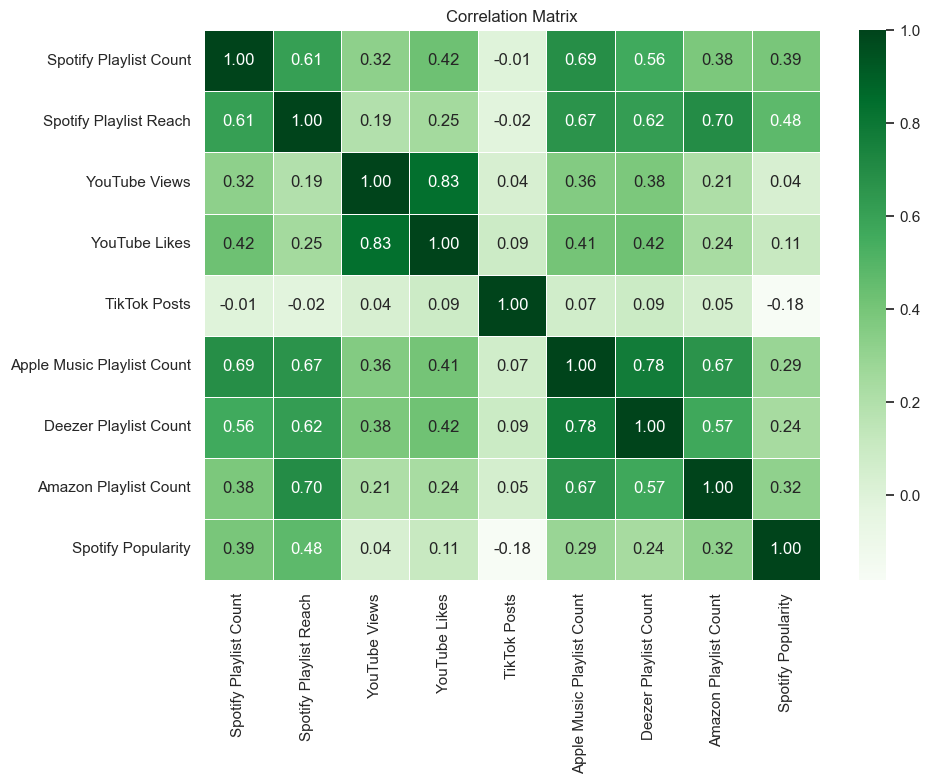

In [6]:
# Correlation heatmap of numeric columns
corr_cols = [
    "Spotify Playlist Count", "Spotify Playlist Reach",
    "YouTube Views", "YouTube Likes", "TikTok Posts",
    "Apple Music Playlist Count", "Deezer Playlist Count",
    "Amazon Playlist Count", "Spotify Popularity"
]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="Greens", ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

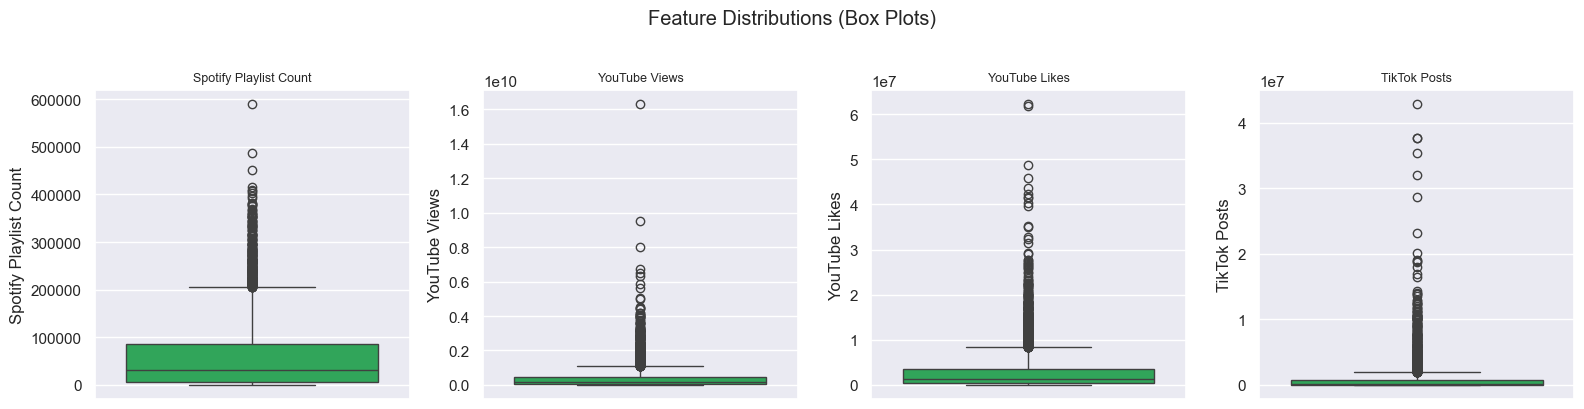

In [7]:
# Box plots of selected features
plot_features = ["Spotify Playlist Count", "YouTube Views", "YouTube Likes", "TikTok Posts"]
fig, axes = plt.subplots(1, len(plot_features), figsize=(16, 4))
for i, feat in enumerate(plot_features):
    sns.boxplot(y=df[feat].dropna(), ax=axes[i], color="#1db954")
    axes[i].set_title(feat, fontsize=9)
plt.suptitle("Feature Distributions (Box Plots)", y=1.02)
plt.tight_layout()
plt.show()

## Define Features & Target
- Select 9 features (playlist counts, views, likes, etc.)
- Target: Spotify Popularity
- Drop rows with missing values

In [8]:
features = [
    "Spotify Playlist Count", "Spotify Playlist Reach",
    "YouTube Views", "YouTube Likes", "TikTok Posts",
    "Apple Music Playlist Count", "Deezer Playlist Count",
    "Amazon Playlist Count", "Explicit Track"
]
target = "Spotify Popularity"

data = df[features + [target]].dropna()
X = data[features]
y = data[target]
print(f"Samples: {len(data)}")

Samples: 2561


## Train/Test Split
- 80/20 split of the data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling
- StandardScaler applied to training data, then applied to test data
- Required for LinearRegression; also good practice in general

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler mean:", np.round(scaler.mean_, 2))
print("Scaler scale:", np.round(scaler.scale_, 2))

Scaler mean: [9.13182000e+04 3.17871440e+07 4.81952905e+08 3.68368801e+06
 7.97687510e+05 7.41900000e+01 3.97200000e+01 2.78400000e+01
 3.90000000e-01]
Scaler scale: [7.56759200e+04 3.22721859e+07 7.66243276e+08 5.10088618e+06
 2.00087705e+06 7.84000000e+01 5.90300000e+01 2.75200000e+01
 4.90000000e-01]


## Train Model
- Random Forest Regressor with 100 trees
- Train on training data

In [11]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Evaluation
- Calculate MAE, RMSE and R² on test data

In [12]:
y_pred_rf = model_rf.predict(X_test_scaled)
print("=== Random Forest ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.2f}")

=== Random Forest ===
MAE:  4.33
RMSE: 6.78
R²:   0.50


## Feature Importance
- Display importance score of each feature

In [13]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model_rf.feature_importances_
}).sort_values("Importance", ascending=False)
importance

,Feature,Importance
1,Spotify Playlist Reach,0.413860
0,Spotify Playlist Count,0.116404
6,Deezer Playlist Count,0.089893
4,TikTok Posts,0.084288
3,YouTube Likes,0.074540
2,YouTube Views,0.070344
5,Apple Music Playlist Count,0.069833
7,Amazon Playlist Count,0.065587
8,Explicit Track,0.015251


## Linear Regression (for Browser Export)
A LinearRegression model is trained additionally – its coefficients and intercept can be exported
directly as JSON and used in the browser without any ML library.

In [14]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
print("=== Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.2f}")

print("\nCoefficients:")
for name, coef in zip(features, model_lr.coef_):
    print(f"  {name}: {coef:.6f}")
print(f"  Intercept: {model_lr.intercept_:.4f}")

=== Linear Regression ===
MAE:  4.49
RMSE: 7.11
R²:   0.45

Coefficients:
  Spotify Playlist Count: 1.952340
  Spotify Playlist Reach: 5.286660
  YouTube Views: 0.054276
  YouTube Likes: 0.496024
  TikTok Posts: -1.273811
  Apple Music Playlist Count: -0.578695
  Deezer Playlist Count: -1.662457
  Amazon Playlist Count: 0.165244
  Explicit Track: -1.126745
  Intercept: 67.3359


## Export Trained Model
- Export LinearRegression coefficients + intercept
- Export StandardScaler mean + scale so the browser can apply the same preprocessing
- The browser performs: `prediction = dot(scale(input), coef) + intercept`

In [15]:
model_data = {
    "feature_names": features,
    "coef": model_lr.coef_.tolist(),
    "intercept": float(model_lr.intercept_),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist()
}

with open("model_data.json", "w") as f:
    json.dump(model_data, f, indent=2)

print("Exported model_data.json")
print(f"  Features: {len(features)}")
print(f"  Intercept: {model_data['intercept']:.4f}")

Exported model_data.json
  Features: 9
  Intercept: 67.3359


## Deployment

The web interface is deployed via **GitHub Pages** and publicly accessible at:

🔗 **https://philipp2006.github.io/Model_Deployment/**

Repository: https://github.com/philipp2006/Model_Deployment